In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

plt.rcParams["font.family"] = "Times New Roman"

In [27]:
#file 1 cols 1-3, file 2 cols 4

file_1 = "Einstein_A_Good.xlsx"
file_2 = "Einstein_A_take_3.xlsx"

cols1 = [["I_80", "F_80"], ["I_90","F_90"],["I_100_0","F_100_0"], ["I_110","F_110"], ["I_120","F_120"],["I_100_1","F_100_1"],["I_130","F_130"]]
cols2 = [["I_100_1","F_100_1"],["I_130","F_130"]]
cols3 = [["I_80", "F_80"], ["I_90","F_90"], ["I_120","F_120"],["I_110","F_110"]]
cols4 = [["I_77","F_77"],["I_90","F_90"],["I_110","F_110"],["I_140","F_140"],["I_170","F_170"], ["I_200", "F_200"], ["I_250","F_250"]]
cols = cols4

bins = np.array([20, 30, 40, 50, 60, 70, 80, 90, 100])

df = pd.read_excel(file_2)

# Model
def Amplitude_model(x,A0,T):
    omega = 2* np.pi*x
    return((A0*T)/np.sqrt(1+(omega**2)*(T**2)))

p0_Amplitude_model = [0.01, 0.003]

bounds_Amplitude_model = (
    [0, 0],  # Lower bounds
    [np.inf, np.inf]  # Upper bounds
)



def temperature_dependence(T, t0, a):
    return t0*np.exp(a*(T-298))

p0_temperature_dependence = [0.003, #roomtemp lifetime
      -1, #a
      ]

bounds_temperature_dependence = [
    [0, -np.inf], #lower
    [np.inf, 0] #upper
]

def model_uncertainty(x, pop, cov):

    A0, T = pop
    omega = 2*np.pi*x
    denom = np.sqrt(1 + (omega**2)*(T**2))

    dA0 = T / denom
    dT  = A0 / (1 + (omega**2)*(T**2))**(3/2)

    var = (
        dA0**2 * cov[0,0] +
        dT**2  * cov[1,1] +
        2*dA0*dT*cov[0,1]
    )

    return np.sqrt(var)

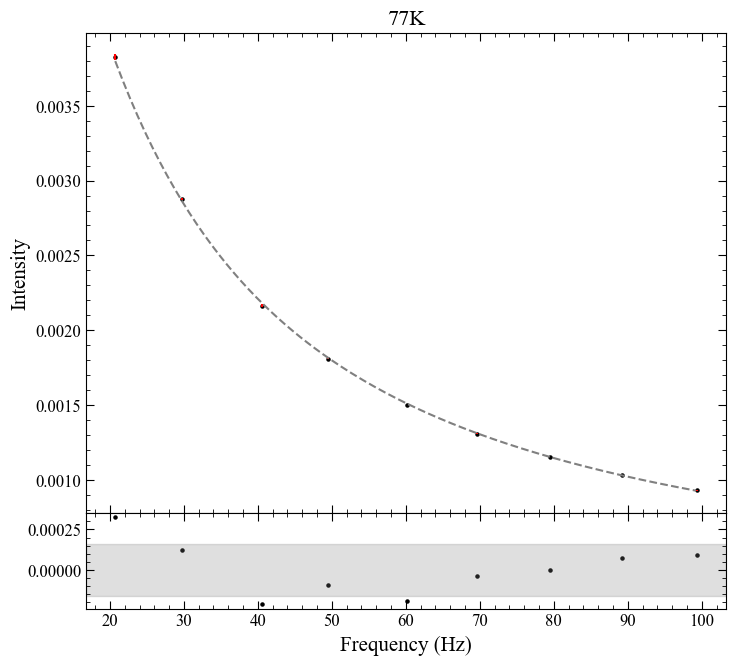

77K time const: 0.01222 time err: 0.00016
77K A0: 0.58406 A0_err: 0.00046


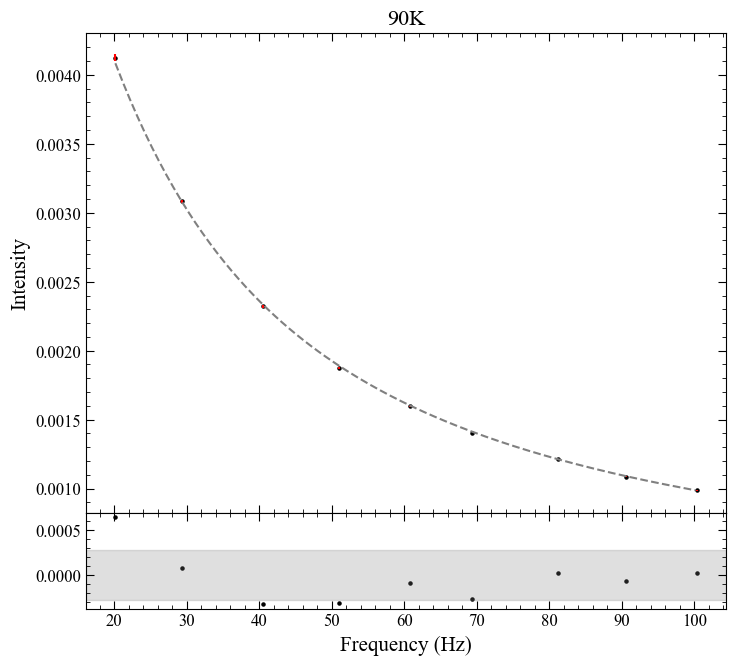

90K time const: 0.01144 time err: 0.00016
90K A0: 0.62777 A0_err: 0.00040


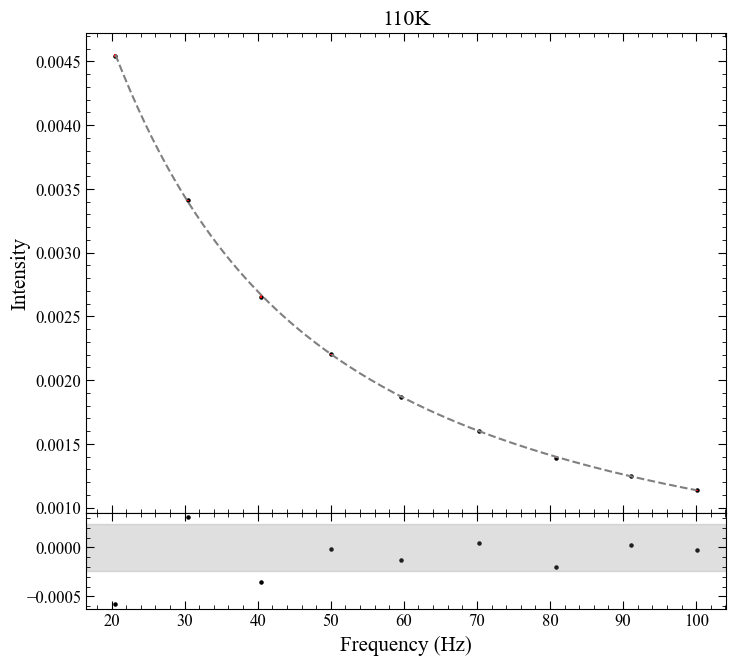

110K time const: 0.01086 time err: 0.00007
110K A0: 0.72162 A0_err: 0.00053


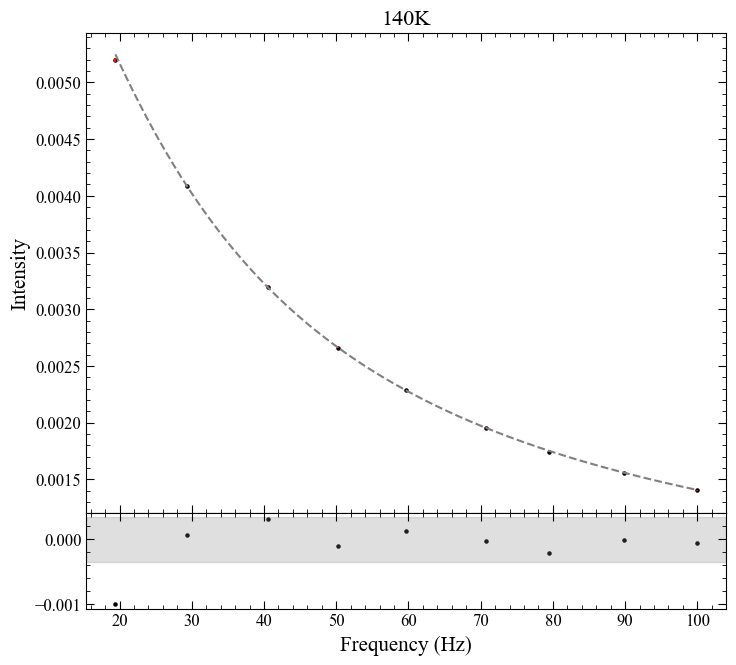

140K time const: 0.00832 time err: 0.00005
140K A0: 0.89907 A0_err: 0.00061


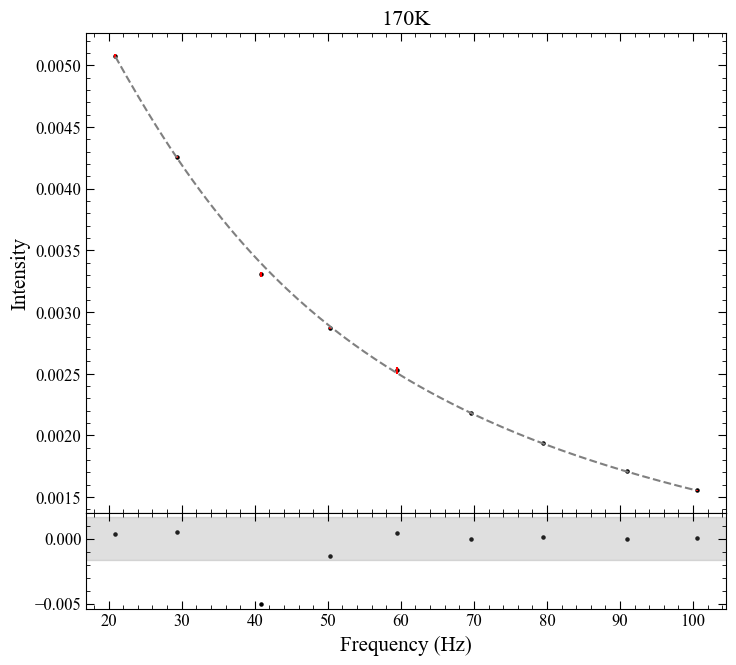

170K time const: 0.00671 time err: 0.00003
170K A0: 1.00787 A0_err: 0.00119


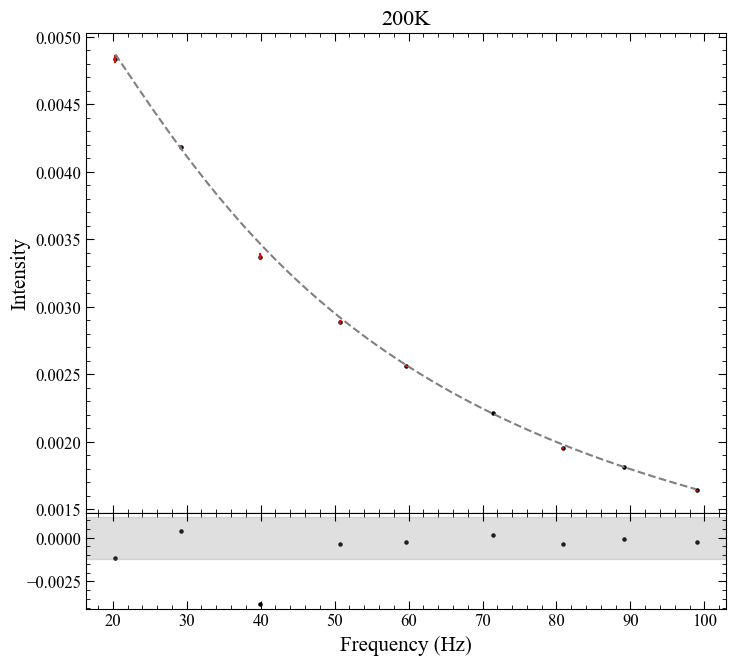

200K time const: 0.00563 time err: 0.00003
200K A0: 1.06594 A0_err: 0.00133


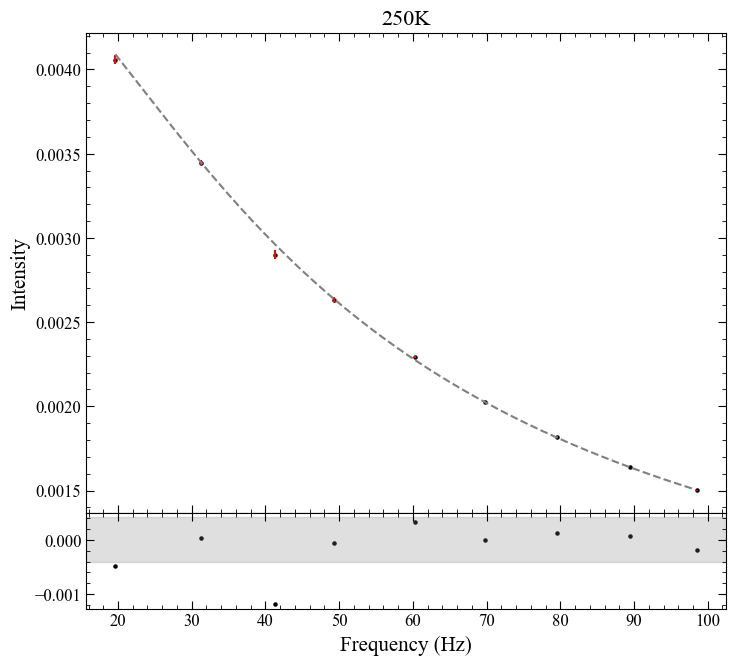

250K time const: 0.00487 time err: 0.00003
250K A0: 0.98038 A0_err: 0.00100


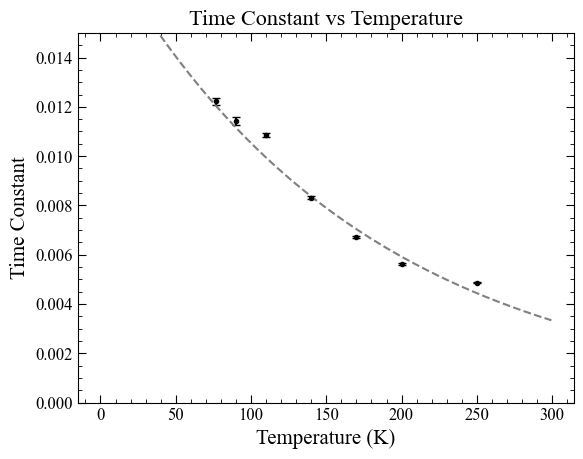

Estimated t_0 at 0 kelvin is 0.00337 s
Estimated A at 0 kelvin is 297.09954 1/s
Estimated t_0 at 298 kelvin is 0.00337 s


In [28]:
# Dictionary to store results by temperature
results = {}

for I_col, F_col in cols:

    # Extract temperature from column name
    temp = I_col.split("_")[1] + "K"

    xdata = df[F_col].to_numpy()
    ydata = df[I_col].to_numpy()

    freq_values = []
    freq_uncertainty = []

    int_values = []
    int_uncertainty = []

    # Bin averaging
    for b in bins:

        mask = (xdata > b - 2) & (xdata < b + 2)

        frequency = xdata[mask]
        intensity = ydata[mask]

        if len(frequency) == 0:
            continue

        mean_freq = np.mean(frequency)
        err_freq = np.std(frequency) / np.sqrt(len(frequency))

        mean_intensity = np.mean(intensity)
        err_intensity = np.std(intensity) / np.sqrt(len(intensity))

        freq_values.append(mean_freq)
        freq_uncertainty.append(err_freq)

        int_values.append(mean_intensity)
        int_uncertainty.append(err_intensity)

    freq_values = np.array(freq_values)
    freq_uncertainty = np.array(freq_uncertainty)
    int_values = np.array(int_values)
    int_uncertainty = np.array(int_uncertainty)

    # Fit amplitude model
    pop_amp, cov_amp = curve_fit(
        Amplitude_model,
        freq_values,
        int_values,
        sigma=int_uncertainty,
        absolute_sigma=True,
        p0=p0_Amplitude_model,
        bounds=bounds_Amplitude_model
    )

    A0_fit, T_fit = pop_amp
    A0_err, T_err = np.sqrt(np.diag(cov_amp))

    # Einstein A coefficient and propagated error
    A_coeff = 1 / T_fit
    A_err = np.abs(1 /(T_fit+T_err)-1/T_fit)

    # Store results
    results[temp] = {
        "freq": freq_values,
        "freq_err": freq_uncertainty,
        "int": int_values,
        "int_err": int_uncertainty,
        "A0": A0_fit,
        "A0_err": A0_err,
        "time_const": T_fit,
        "time_err": T_err,
        "A_coeff": A_coeff,
        "A_err": A_err,
        "pop": pop_amp,
        "cov": cov_amp
    }

    T_model_range = np.arange(freq_values[0],freq_values[-1],0.5)
    n_residual = (int_values-Amplitude_model(freq_values, *pop_amp))/freq_uncertainty

    fig = plt.figure(1)
    fig.add_axes([0,0,1,1])
    plt.scatter(freq_values, int_values, color = "black", s = 5)
    plt.errorbar(freq_values, int_values, yerr=int_uncertainty, color = "red", fmt = "none")
    plt.plot(T_model_range, Amplitude_model(T_model_range, *pop_amp), color = "grey", linestyle = "--")
    plt.ylabel("Intensity")
    plt.title(temp)

    plt.minorticks_on()
    plt.tick_params(which="major", size=6, direction="in",
                    top=True, right=True, left=True, bottom = True)
    plt.tick_params(which="minor", size=3, direction="in",
                    top=True, right=True, left=True, bottom = True)

    fig.add_axes([0,-0.2,1,0.2])
    plt.xlabel("Frequency (Hz)")
    plt.minorticks_on()
    plt.tick_params(which="major", size=6, direction="in",
                    top=True, right=True, left=True, bottom = True)
    plt.tick_params(which="minor", size=3, direction="in",
                    top=True, right=True, left=True, bottom = True)
    plt.scatter(freq_values, n_residual, s = 5, color = "black")
    plt.axhspan(-np.std(n_residual), np.std(n_residual), color = "grey", alpha = 0.25)
    plt.show()

    print(f"{temp} time const: {T_fit:.5f} time err: {T_err:.5f}")
    print(f"{temp} A0: {A0_fit:.5f} A0_err: {A0_err:.5f}")

# Extract Temperature vs A coefficient

temperatures = []
T_values = []
T_errors = []
A_values = []
A_errors = []

for temp in results:
    T_val = float(temp.replace("K", ""))

    temperatures.append(T_val)
    T_values.append(results[temp]["time_const"])
    T_errors.append(results[temp]["time_err"])
    A_values.append(results[temp]["A_coeff"])
    A_errors.append(results[temp]["A_err"])

temperatures = np.array(temperatures)
T_values = np.array(T_values)
T_errors = np.array(T_errors)
A_values = np.array(A_values)
A_errors = np.array(A_errors)

# Sort by temperature
order = np.argsort(temperatures)
temperatures = temperatures[order]
T_values = T_values[order]
T_errors = T_errors[order]
A_values = A_values[order]
A_errors = A_errors[order]
T_values = np.abs(T_values)

# fit temperature model

pop_temp, cov_temp = curve_fit(temperature_dependence,
                             temperatures,
                             T_values,
                             sigma=T_errors,
                             absolute_sigma=True,
                             p0=p0_temperature_dependence,
                             bounds=bounds_temperature_dependence,
                               maxfev=10000)

# Plot Temperature vs time coeff
trange = np.arange(0.0000001,300,0.5)
plt.figure()

plt.errorbar(
    temperatures,
    T_values,
    yerr=T_errors,
    fmt='o',
    markersize =3,
    capsize =3,
    color ="black",
)

plt.plot(trange, temperature_dependence(trange, *pop_temp), color = "grey", linestyle = "--")

plt.xlabel("Temperature (K)")
plt.ylabel("Time Constant")
plt.title("Time Constant vs Temperature")
plt.ylim([0,0.015])

plt.minorticks_on()
plt.tick_params(which="major", size=6, direction="in",
                    top=True, right=True, left=True, bottom = True)
plt.tick_params(which="minor", size=3, direction="in",
                    top=True, right=True, left=True, bottom = True)

plt.show()

print(f"Estimated t_0 at 0 kelvin is {pop_temp[0]:.5f} s")
print(f"Estimated A at 0 kelvin is {1/pop_temp[0]:.5f} 1/s")
print(f"Estimated t_0 at 298 kelvin is {temperature_dependence(298, *pop_temp):.5f} s")

In [29]:
data = {
    "Temperatures": temperatures,
    "Lifetimes": T_values,
    "Errors": T_errors,
    "t0": pop_temp[0],
    "a": pop_temp[1],
    "t0_err": np.sqrt(cov_temp[0][0]),
    "a_err": np.sqrt(cov_temp[1][1]),
}

df_data = pd.DataFrame(data)

df_data.to_csv("Amplitude_Data.csv")
print(np.sqrt(cov_temp[0][0]))
print(pop_temp[0])

2.4876606876254315e-05
0.003365875235597677


# Frequency vs Intensity for report

In [30]:
print(results)

{'77K': {'freq': array([20.72167797, 29.70038028, 40.50205357, 49.54570455, 60.200088  ,
       69.60610959, 79.45328049, 89.2810102 , 99.36962903]), 'freq_err': array([0.08422235, 0.06750197, 0.09145228, 0.055617  , 0.03917977,
       0.06762575, 0.08405437, 0.04339299, 0.02884761]), 'int': array([0.00382561, 0.00287458, 0.00216543, 0.00180934, 0.00150158,
       0.00130993, 0.00115432, 0.00103335, 0.00093015]), 'int_err': array([1.76978538e-05, 7.42553223e-06, 1.18206694e-05, 2.60149782e-06,
       2.38131887e-06, 2.02158819e-06, 1.98363906e-06, 1.10384414e-06,
       1.37220269e-06]), 'A0': np.float64(0.5840621190268125), 'A0_err': np.float64(0.00046268697613305586), 'time_const': np.float64(0.012219290267643197), 'time_err': np.float64(0.00015868219763665018), 'A_coeff': np.float64(81.83781366156839), 'A_err': np.float64(1.0491382298694418), 'pop': array([0.58406212, 0.01221929]), 'cov': array([[ 2.14079238e-07, -5.20682663e-08],
       [-5.20682663e-08,  2.51800398e-08]])}, '90K':

In [31]:
plt.rcParams.update({
    "font.size": 14,        # default text size
    "axes.titlesize": 16,   # title size
    "axes.labelsize": 15,   # axis labels
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.rcParams.update({
    "font.family": "Times New Roman",  # Use Times New Roman for all text
    "mathtext.fontset": "custom",      # Use custom font for math
    "mathtext.rm": "Times New Roman",  # Roman font in math
    "mathtext.it": "Times New Roman:italic",  # Italic font in math
    "mathtext.bf": "Times New Roman:bold",    # Bold font in math
    "text.usetex": False
})

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

residual_band= Patch(
    facecolor="grey",
    alpha=0.12,
    label=r"$1\sigma$ Residuals"
)

# prep
red_cb = "#e41a1c"
blue_cb = "#377eb8"
purple_cb = "#984ea3"

laptop_savepath_amplitude = r"C:\Users\sebas\Documents\Durham Work\Year 3\Advanced Lab\Report Figures\amplitude_plot.png"
pc_savepath_amplitude = r"C:\Users\User\Documents\Durham Work\Year 3\Advanced_Lab\Report\Figures\amplitude_plot.png"

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as colors
import matplotlib.cm as cm

cmap = LinearSegmentedColormap.from_list(
    "red_blue_gradient",
    [blue_cb, red_cb],
    N=256
)

temps = np.array([float(t.replace("K","")) for t in results.keys()])
norm = colors.Normalize(vmin=temps.min(), vmax=temps.max())

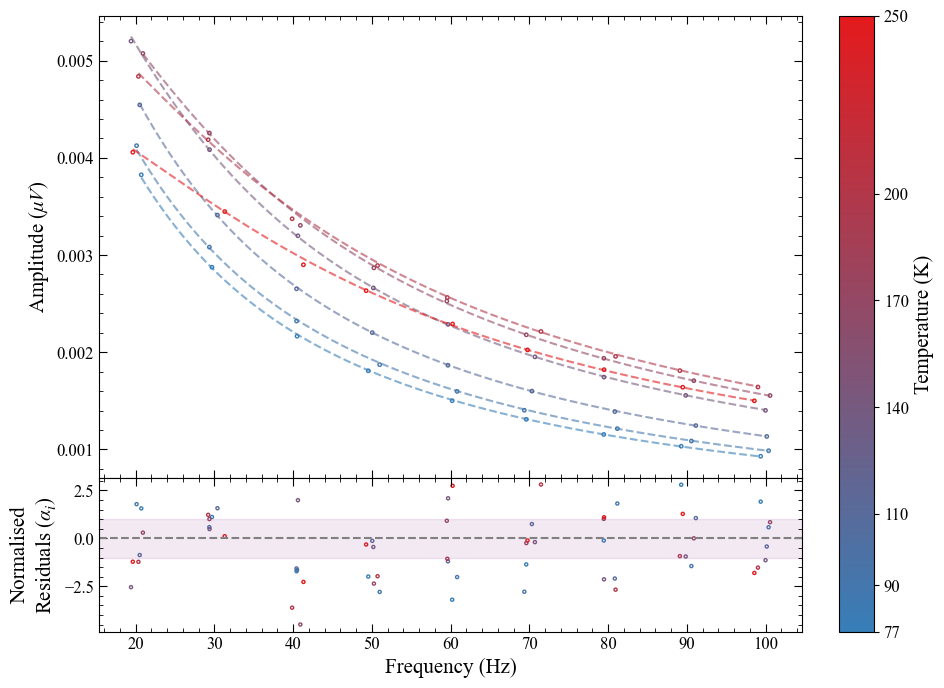

In [32]:
fig = plt.figure(figsize=(10, 8))

gs = fig.add_gridspec(
    2, 2,
    hspace=0,
    wspace=0.1,
    height_ratios=[3, 1],
    width_ratios=[20, 1],
)

ax_main = fig.add_subplot(gs[0, 0])
ax_res = fig.add_subplot(gs[1, 0], sharex=ax_main)

ax_cb = fig.add_subplot(gs[:, 1])

ax_main.set_ylabel("Amplitude ($\\mu V$)")
ax_res.set_ylabel("Normalised\nResiduals ($\\alpha_i$)")
ax_res.set_xlabel("Frequency (Hz)")

###########
# Main Plot
###########

for temp, data in results.items():

    pop = data["pop"]

    colour = cmap(norm(float(temp.replace("K",""))))

    ax_main.scatter(
        data["freq"],
        data["int"],
        s=6,
        facecolor="none",
        edgecolor=colour
    )

    x_fit = np.linspace(data["freq"].min(), data["freq"].max(), 1000)

    ax_main.plot(
        x_fit,
        Amplitude_model(x_fit, *pop),
        linestyle="--",
        color=colour,
        alpha=0.6
    )

###########
# Residuals
###########
for temp, data in results.items():

    pop = data["pop"]

    residual = data["int"] - Amplitude_model(data["freq"], *pop)
    residual /= data["int_err"]

    colour = cmap(norm(float(temp.replace("K",""))))

    ax_res.scatter(
        data["freq"],
        residual,
        marker="o",
        facecolor="none",
        edgecolor=colour,
        s=5
    )

ax_res.axhspan(-1, 1, color=purple_cb, alpha=0.12)
ax_res.axhline(0, color="grey", linestyle="--")

###########
# Color Bar
###########

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=ax_cb,
    orientation="vertical"
)

cbar.set_label("Temperature (K)")
tick_values = sorted([float(t.replace("K","")) for t in results.keys()])
cbar.set_ticks(tick_values)

#########
# Styling
#########

for ax in [ax_main, ax_res]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True, bottom=True, left=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True, bottom=True, left=True)

plt.savefig(pc_savepath_amplitude,
            dpi=150,
            bbox_inches = "tight")
plt.show()

# Time constant vs Temperature for report

In [24]:
# prep
laptop_savepath_timeconst = r"C:\Users\sebas\Documents\Durham Work\Year 3\Advanced Lab\Report Figures\timeconst.png"
pc_savepath_timeconst = r"C:\Users\User\Documents\Durham Work\Year 3\Advanced_Lab\Report\Figures\timeconst.png"

legend_elements = [
    Line2D([0], [0],
           color="black",
           marker = "o",
           linestyle='-',
           markerfacecolor="none", markersize=5, linewidth=1.5,

           label=r"Amplitude Data"),
    residual_band
]

print(pop_temp)

alpha_1 = np.abs(temperature_dependence(298,*pop_temp) - temperature_dependence(298,pop_temp[0]+np.sqrt(cov_temp[0][0]), pop_temp[1]))
alpha_2 = np.abs(temperature_dependence(298,*pop_temp) - temperature_dependence(298,pop_temp[0], pop_temp[1]+np.sqrt(cov_temp[1][1])))
# alpha_3 = np.abs(temperature_dependence(298,*pop_temp) - temperature_dependence(298,pop_temp[0], pop_temp[1], pop_temp[2]+np.sqrt(cov_temp[2][2])))

t_0_err = np.sqrt(alpha_1+alpha_2)

scale_factor = 1

[ 0.00336588 -0.0057599 ]


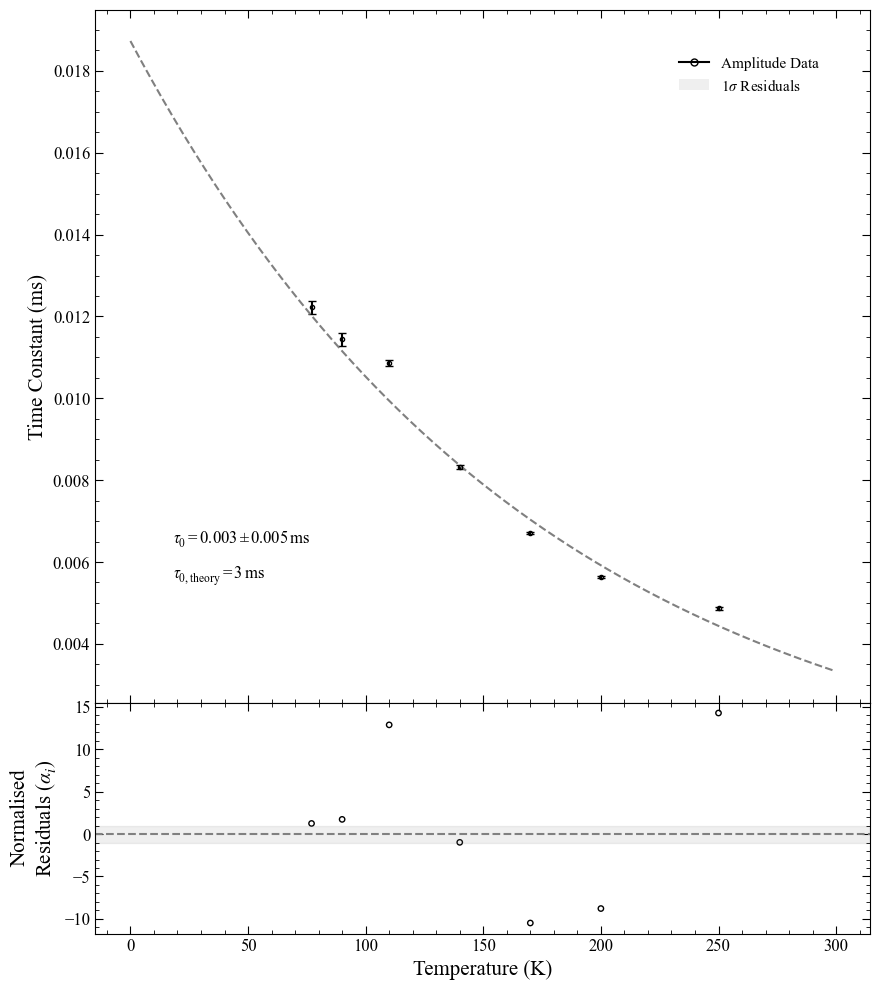

In [25]:
fig = plt.figure(figsize = (10,12))

gs = fig.add_gridspec(
    2, 1,
    height_ratios = [3,1],
    hspace = 0
)

ax_main = fig.add_subplot(gs[0])
ax_res = fig.add_subplot(gs[1], sharex = ax_main)

###########
# main plot
###########

ax_main.errorbar(temperatures, T_values*scale_factor, yerr=T_errors*scale_factor,
    fmt='o', markersize =3, capsize =3, color ="black", markerfacecolor = "none"
    )

ax_main.plot(trange, temperature_dependence(trange, *pop_temp)*scale_factor,
             color = "grey", linestyle = "--")

ax_main.set_ylabel("Time Constant (ms)")

ax_main.legend(
    handles = legend_elements,
    loc = "upper right",
    bbox_to_anchor = (0.95, 0.95),
    borderpad = 0.3,
    frameon = False
)

ax_main.text(
    0.1, 0.25,
    rf"$\tau_0 = {temperature_dependence(298, *pop_temp)*scale_factor:.3f}\, ±\, {(t_0_err*scale_factor):.3f}\,\mathrm{{ms}}$",
    transform=ax_main.transAxes,
    fontsize=12,
    verticalalignment='top'
)
ax_main.text(
    0.1, 0.2,
    rf"$\tau_{{0,\mathrm{{theory}}}} = 3\,\mathrm{{ms}}$",
    transform=ax_main.transAxes,
    fontsize=12,
    verticalalignment='top'
)

##############
#residual plot
##############

residuals = (T_values-temperature_dependence(temperatures, *pop_temp))/T_errors
ax_res.scatter(temperatures, residuals,
               marker = "o", label = temp, s = 15, color = "black", facecolor = "none")

ax_res.axhspan(-1, 1, color = "grey", alpha = 0.12)
ax_res.axhline(0, color = "grey", linestyle = "--")
ax_res.set_xlabel("Temperature (K)")
ax_res.set_ylabel(r"Normalised" "\n" r"Residuals ($\alpha_i$)")


# Styling
for ax in [ax_main, ax_res]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

for ax in [ax_main, ax_res]:
    for label in ax.get_xticklabels()+ ax.get_yticklabels():
        label.set_bbox(dict(
            facecolor="white",
            edgecolor="none",
            pad=1.0
        ))

plt.savefig(pc_savepath_timeconst, bbox_inches = "tight", dpi = 150)
plt.show()